In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#https://drive.google.com/file/d/1dTrJe1tpR1rQ5e-53J11eixHqIocjiBg/view?usp=sharing
file_id="1dTrJe1tpR1rQ5e-53J11eixHqIocjiBg"
url=f"https://drive.google.com/uc?id={file_id}"
df=pd.read_csv(url)
df.head()


,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170


In [2]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [3]:
df.isnull().sum()

,0
Price,0
Age_08_04,0
KM,0
Fuel_Type,0
HP,0
Automatic,0
cc,0
Doors,0
Cylinders,0
Gears,0


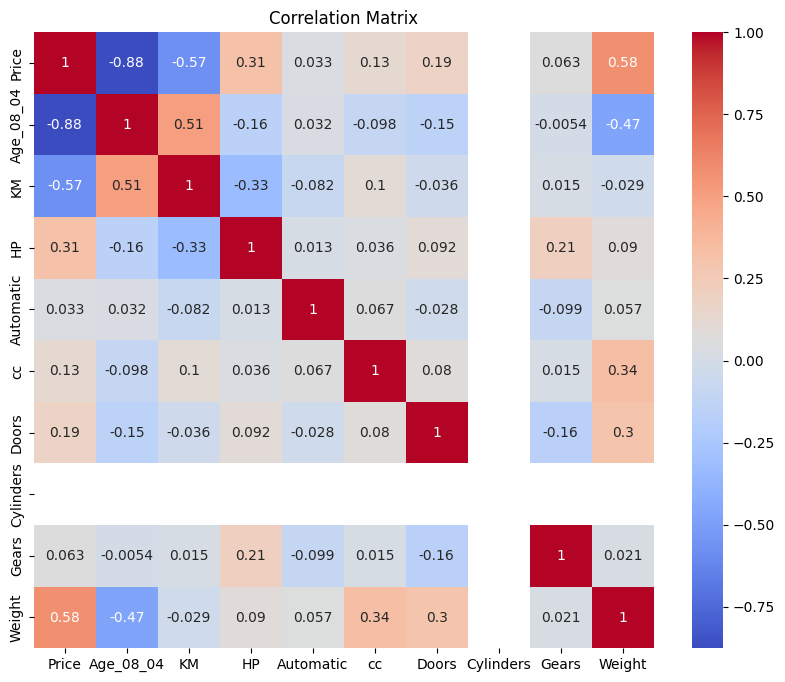

In [4]:
#Correlation Matrix
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

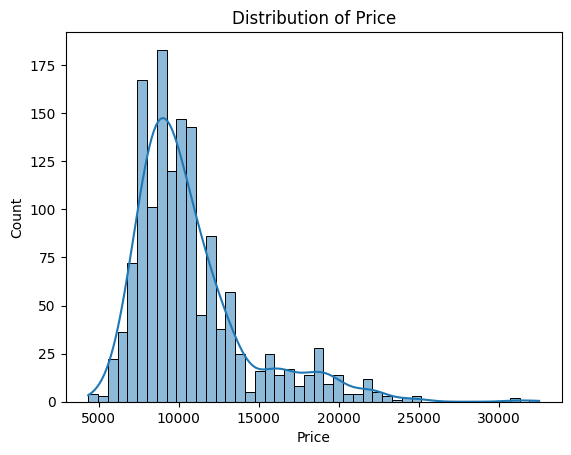

In [5]:
#Distribution of Price
sns.histplot(df["Price"], kde=True)
plt.title("Distribution of Price")
plt.show()


In [6]:
#Remove Constant Feature
df["Cylinders"].unique()
df = df.drop("Cylinders", axis=1)

In [7]:
#Encode Categorical Variable
df = pd.get_dummies(df, columns=["Fuel_Type"], drop_first=True)

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error

In [12]:
#Define Features and Target
X = df.drop("Price", axis=1)
y = df["Price"]


In [15]:
#TASK 2: Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [16]:
#Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [17]:
#TASK 3: Build Multiple Linear Regression Models
model1 = LinearRegression()
model1.fit(X_train, y_train)

y_pred1 = model1.predict(X_test)


In [18]:
#Interpret Coefficients
coeff_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model1.coef_
})

print(coeff_df)


            Feature  Coefficient
0         Age_08_04  -120.830458
1                KM    -0.016231
2                HP    14.039479
3         Automatic   148.830927
4                cc    -0.030372
5             Doors   -60.310974
6             Gears   551.600710
7            Weight    25.884958
8  Fuel_Type_Diesel   -68.548757
9  Fuel_Type_Petrol  1370.808910


In [19]:
#Reduced Model (Important Predictors Only)
important_features = ["Age_08_04", "KM", "Weight", "HP"]

X2 = df[important_features]

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y, test_size=0.2, random_state=42
)

model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y_pred2 = model2.predict(X2_test)


In [27]:
print(X.dtypes)

Age_08_04           int64
KM                  int64
HP                  int64
Automatic           int64
cc                  int64
Doors               int64
Gears               int64
Weight              int64
Fuel_Type_Diesel     bool
Fuel_Type_Petrol     bool
dtype: object


In [28]:
import statsmodels.api as sm

# Convert boolean columns to integer
X = X.astype(int)

# Add constant
X_sm = sm.add_constant(X)

# Fit OLS model
model = sm.OLS(y, X_sm).fit()

# Show summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.865
Model:                            OLS   Adj. R-squared:                  0.864
Method:                 Least Squares   F-statistic:                     912.3
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        10:12:30   Log-Likelihood:                -12369.
No. Observations:                1436   AIC:                         2.476e+04
Df Residuals:                    1425   BIC:                         2.482e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -9861.0292   1529.450  

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Remove weakest feature
X_new = X.drop("cc", axis=1)

# Train-test split
X_train_new, X_test_new, y_train, y_test = train_test_split(
    X_new, y,
    test_size=0.2,
    random_state=42
)

# Train model
model3 = LinearRegression()
model3.fit(X_train_new, y_train)

# Predictions
y_pred3 = model3.predict(X_test_new)

# Evaluation
r2_3 = r2_score(y_test, y_pred3)
rmse_3 = np.sqrt(mean_squared_error(y_test, y_pred3))

print("Model 3 R² Score:", r2_3)
print("Model 3 RMSE:", rmse_3)

Model 3 R² Score: 0.8348264251697731
Model 3 RMSE: 1484.5457660574468


In [20]:
#MODEL 3: Ridge Regression
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_pred = ridge.predict(X_test_scaled)


In [21]:
#MODEL 4: Lasso Regression
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

lasso_pred = lasso.predict(X_test_scaled)


In [22]:
print("Linear R2:", r2_score(y_test, y_pred1))
print("Reduced R2:", r2_score(y2_test, y_pred2))
print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))


Linear R2: 0.8348888040611084
Reduced R2: 0.8506068681500583
Ridge R2: 0.8350462635431574
Lasso R2: 0.8349116135580272


In [23]:
#R2
from sklearn.metrics import r2_score

r2_linear = r2_score(y_test, y_pred1)
print("Linear Regression R2:", r2_linear)
print("Ridge R2:", r2_score(y_test, ridge_pred))
print("Lasso R2:", r2_score(y_test, lasso_pred))


Linear Regression R2: 0.8348888040611084
Ridge R2: 0.8350462635431574
Lasso R2: 0.8349116135580272


In [24]:
#RMSE (Root Mean Squared Error)
from sklearn.metrics import mean_squared_error
import numpy as np

rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred1))
print("Linear Regression RMSE:", rmse_linear)
print("Ridge RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("Lasso RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))


Linear Regression RMSE: 1484.2654153296505
Ridge RMSE: 1483.557506308159
Lasso RMSE: 1484.1628889184237



Interview Questions:

1. What is Normalization & Standardization and how is it helpful?
Normalization

Normalization is the process of scaling data values to a fixed range, usually between 0 and 1.


It is useful when features have different ranges and we want all variables to contribute equally to the model.

Example:
If Age ranges from 1–100 and Salary ranges from 10,000–100,000, normalization brings them to the same scale.


2. What techniques can be used to address multicollinearity in Multiple Linear Regression?

Multicollinearity occurs when independent variables are highly correlated with each other, making coefficient estimation unstable.

Techniques to handle multicollinearity:
1. Remove Highly Correlated Features
If two variables are strongly correlated, remove one of them.

2. Use VIF (Variance Inflation Factor)

VIF helps detect multicollinearity.

3. Apply Ridge Regression

Ridge reduces coefficient values and handles multicollinearity effectively.

4. Apply Lasso Regression

Lasso can shrink some coefficients to zero and perform feature selection.

5. Principal Component Analysis (PCA)

PCA transforms correlated variables into new uncorrelated components, reducing multicollinearity.